### 1. Pemuatan Data, Pembersihan Awal, dan Visualisasi Distribusi Target

TAHAP 1: PEMUATAN DATA & PEMBERSIHAN AWAL
Dimensi data mentah awal : 29601 baris, 24 kolom
Dimensi data setelah eliminasi 'Off season': 28277 baris

[OUTPUT NYATA] Distribusi Frekuensi Target Biner:
  - Kategori Aman (0)  : 22580 baris (79.85%)
  - Kategori Bahaya (1):  5697 baris (20.15%)


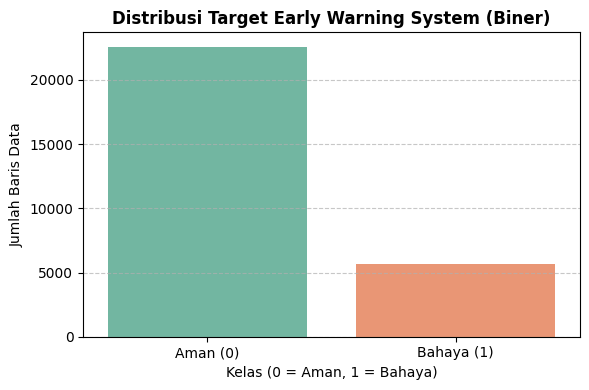

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. PEMUATAN DATA
path_data = '../data/asap_indonesia_master_2001.csv'
df = pd.read_csv(path_data)

print("="*60)
print("TAHAP 1: PEMUATAN DATA & PEMBERSIHAN AWAL")
print("="*60)
print(f"Dimensi data mentah awal : {df.shape[0]} baris, {df.shape[1]} kolom")

# 2. FILTER DATA 'OFF SEASON'
df = df[df['w_crop_na'] != 'Off season'].copy()
print(f"Dimensi data setelah eliminasi 'Off season': {df.shape[0]} baris")

# 3. TRANSFORMASI TARGET MENJADI BINER
def ubah_ke_biner(status):
    status = str(status)
    if status == 'No warning': 
        return 0
    elif any(kategori in status for kategori in ['exceptional', 'level 1', 'level 2', 'level 3', 'level 4']): 
        return 1
    else: 
        return 0 

df['target_biner'] = df['w_crop_na'].apply(ubah_ke_biner)

# 4. PENAYANGAN OUTPUT NYATA TAHAP 1
print("\n[OUTPUT NYATA] Distribusi Frekuensi Target Biner:")
distribusi_target = df['target_biner'].value_counts()
persentase_target = df['target_biner'].value_counts(normalize=True) * 100
for kelas, jumlah in distribusi_target.items():
    label = "Aman (0)" if kelas == 0 else "Bahaya (1)"
    print(f"  - Kategori {label:<10}: {jumlah:>5} baris ({persentase_target[kelas]:.2f}%)")

# Visualisasi Distribusi Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target_biner', palette='Set2')
plt.title('Distribusi Target Early Warning System (Biner)', fontsize=12, fontweight='bold')
plt.xlabel('Kelas (0 = Aman, 1 = Bahaya)', fontsize=10)
plt.ylabel('Jumlah Baris Data', fontsize=10)
plt.xticks([0, 1], ['Aman (0)', 'Bahaya (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Ekstraksi Waktu dan Imputasi Nilai Kosong Berbasis Wilayah

In [2]:
print("="*60)
print("TAHAP 2: EKSTRAKSI TEMPORAL & IMPUTASI DATA HILANG")
print("="*60)

# 1. PENGECEKAN AWAL DATA KOSONG
kolom_soil = 'Soil Moisture (gapfilled historical time series)'
missing_awal = df[kolom_soil].isnull().sum()
print(f"[OUTPUT NYATA] Jumlah data kosong pada '{kolom_soil}' sebelum imputasi: {missing_awal} baris")

# 2. EKSTRAKSI FITUR BULAN
df['date'] = pd.to_datetime(df['date'])
df['month_extracted'] = df['date'].dt.month

# 3. EKSEKUSI IMPUTASI MEDIAN PER PROVINSI
df[kolom_soil] = df.groupby('region_name')[kolom_soil].transform(lambda x: x.fillna(x.median()))

# 4. IMPUTASI FALLBACK GLOBAL (Jika ada wilayah yang seluruh barisnya kosong)
df[kolom_soil] = df[kolom_soil].fillna(df[kolom_soil].median())

# 5. PENAYANGAN OUTPUT NYATA TAHAP 2
missing_akhir = df[kolom_soil].isnull().sum()
print(f"[OUTPUT NYATA] Jumlah data kosong pada '{kolom_soil}' setelah imputasi : {missing_akhir} baris")
print(f"Ekstraksi temporal sukses. Fitur 'month_extracted' telah terbentuk.")

TAHAP 2: EKSTRAKSI TEMPORAL & IMPUTASI DATA HILANG
[OUTPUT NYATA] Jumlah data kosong pada 'Soil Moisture (gapfilled historical time series)' sebelum imputasi: 961 baris
[OUTPUT NYATA] Jumlah data kosong pada 'Soil Moisture (gapfilled historical time series)' setelah imputasi : 0 baris
Ekstraksi temporal sukses. Fitur 'month_extracted' telah terbentuk.


### 3. Penanganan Outlier Menggunakan Metode IQR Winsorization (Capping)

TAHAP 3: DETEKSI & PENANGANAN OUTLIER BERBASIS IQR CAPPING
[OUTPUT NYATA] Perbandingan Deskriptif Nilai Ekstrem (Sebelum vs Sesudah Capping):

Fitur: Rainfall
  - Rentang Awal  : [1.07 s.d 440.80]
  - Batas IQR     : [-65.12 s.d 193.79]
  - Rentang Akhir : [1.07 s.d 193.79]

Fitur: Temperature
  - Rentang Awal  : [19.16 s.d 29.33]
  - Batas IQR     : [22.08 s.d 28.69]
  - Rentang Akhir : [22.08 s.d 28.69]

Fitur: Soil Moisture (gapfilled historical time series)
  - Rentang Awal  : [0.09 s.d 0.46]
  - Batas IQR     : [0.22 s.d 0.43]
  - Rentang Akhir : [0.22 s.d 0.43]

Fitur: SPI - 3 months
  - Rentang Awal  : [-2.49 s.d 2.50]
  - Batas IQR     : [-2.41 s.d 2.74]
  - Rentang Akhir : [-2.41 s.d 2.50]

Fitur: Water Satisfaction Index (WSI)
  - Rentang Awal  : [25.65 s.d 100.00]
  - Batas IQR     : [84.12 s.d 109.22]
  - Rentang Akhir : [84.12 s.d 100.00]

Fitur: Solar Radiation
  - Rentang Awal  : [88976.13 s.d 275264.09]
  - Batas IQR     : [118388.50 s.d 241559.32]
  - Rentang Akhir : [

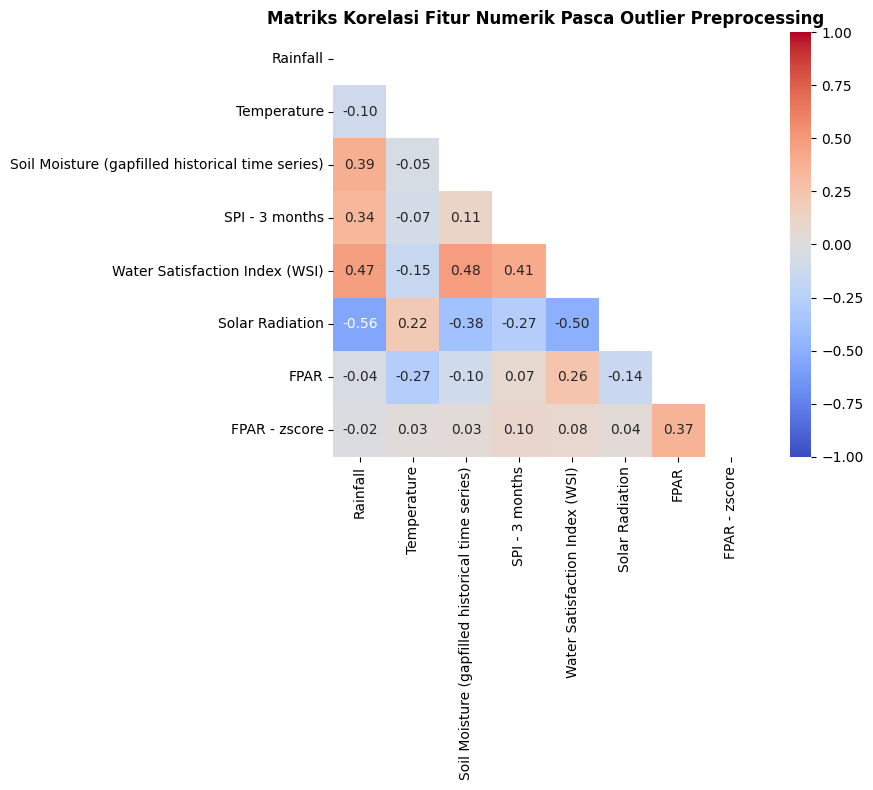

In [3]:
print("="*60)
print("TAHAP 3: DETEKSI & PENANGANAN OUTLIER BERBASIS IQR CAPPING")
print("="*60)

fitur_numerik = [
    'Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)', 
    'SPI - 3 months', 'Water Satisfaction Index (WSI)', 'Solar Radiation', 
    'FPAR', 'FPAR - zscore'
]

print("[OUTPUT NYATA] Perbandingan Deskriptif Nilai Ekstrem (Sebelum vs Sesudah Capping):")

# Tampilan sebelum dan sesudah capping untuk verifikasi matematis
for col in fitur_numerik:
    min_awal = df[col].min()
    max_awal = df[col].max()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Eksekusi Pembatasan Nilai (Capping)
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    
    min_akhir = df[col].min()
    max_akhir = df[col].max()
    
    print(f"\nFitur: {col}")
    print(f"  - Rentang Awal  : [{min_awal:.2f} s.d {max_awal:.2f}]")
    print(f"  - Batas IQR     : [{lower_bound:.2f} s.d {upper_bound:.2f}]")
    print(f"  - Rentang Akhir : [{min_akhir:.2f} s.d {max_akhir:.2f}]")

# Visualisasi Korelasi Fitur Pasca Pembersihan Outlier
plt.figure(figsize=(10, 8))
korelasi = df[fitur_numerik].corr()
mask = np.triu(np.ones_like(korelasi, dtype=bool))
sns.heatmap(korelasi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriks Korelasi Fitur Numerik Pasca Outlier Preprocessing', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 4. Pembentukan Klaster Geografis Berbasis K-Means (K=3)

TAHAP 4: K-MEANS CLUSTERING WILAYAH
[OUTPUT NYATA] Hasil Pembagian 3 Klaster Wilayah di Indonesia:

Klaster 0 (Total: 18 Provinsi):
  Anggota: Banten, Dki Jakarta, Jawa Barat, Jawa Tengah, Kalimantan Barat, Kalimantan S., Kalimantan T., Kalimantan Timur, Kepulauan-riau, Lampung, Maluku, Nangroe A.D., Papua Barat, Riau, Sulawesi Barat, Sulawesi Selatan, Sulawesi Tengg., Sumatera Selatan

Klaster 1 (Total: 9 Provinsi):
  Anggota: Bali, Bangka Belitung, D.I. Yogyakarta, Gorontalo, Jawa Timur, Maluku Utara, Nusatenggara B., Nusatenggara T., Papua

Klaster 2 (Total: 6 Provinsi):
  Anggota: Bengkulu, Jambi, Sulawesi Tengah, Sulawesi Utara, Sumatera Barat, Sumatera Utara


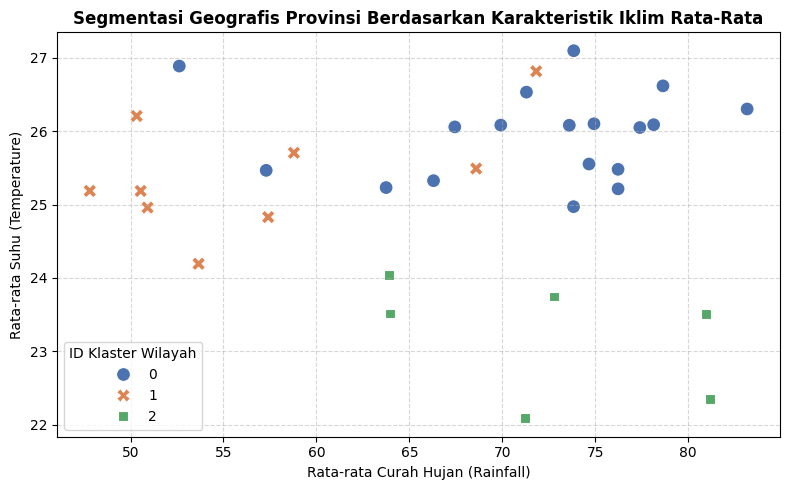

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("="*60)
print("TAHAP 4: K-MEANS CLUSTERING WILAYAH")
print("="*60)

# 1. AGREGASI DATA BERBASIS PROVINSI
df_provinsi = df.groupby('region_name')[['Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)']].mean().reset_index()

# 2. STANDARISASI FITUR KLASTER
scaler_cluster = StandardScaler()
fitur_iklim_scaled = scaler_cluster.fit_transform(df_provinsi[['Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)']])

# 3. EKSEKUSI K-MEANS
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_provinsi['Cluster_Wilayah'] = kmeans.fit_predict(fitur_iklim_scaled)

# 4. GABUNGKAN KEMBALI KE DATA UTAMA
if 'Cluster_Wilayah' in df.columns:
    df = df.drop(columns=['Cluster_Wilayah'])
df = df.merge(df_provinsi[['region_name', 'Cluster_Wilayah']], on='region_name', how='left')

# 5. PENAYANGAN OUTPUT NYATA TAHAP 4 (Daftar Anggota Klaster)
print("[OUTPUT NYATA] Hasil Pembagian 3 Klaster Wilayah di Indonesia:")
for i in range(3):
    anggota_provinsi = df_provinsi[df_provinsi['Cluster_Wilayah'] == i]['region_name'].tolist()
    print(f"\nKlaster {i} (Total: {len(anggota_provinsi)} Provinsi):")
    print(f"  Anggota: {', '.join(anggota_provinsi)}")

# Visualisasi Klaster Berdasarkan Karakteristik Utama (Rainfall vs Temperature)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_provinsi, x='Rainfall', y='Temperature', hue='Cluster_Wilayah', palette='deep', s=100, style='Cluster_Wilayah')
plt.title('Segmentasi Geografis Provinsi Berdasarkan Karakteristik Iklim Rata-Rata', fontsize=12, fontweight='bold')
plt.xlabel('Rata-rata Curah Hujan (Rainfall)', fontsize=10)
plt.ylabel('Rata-rata Suhu (Temperature)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='ID Klaster Wilayah')
plt.tight_layout()
plt.show()

SEL TAMBAHAN: PROOF OF CLUSTER CHARACTERISTICS
[OUTPUT NYATA] Rata-rata Nilai Karakteristik Fisik per Klaster Wilayah:
 Cluster_Wilayah  Rainfall  Temperature  Soil Moisture (gapfilled historical time series)
               0 71.583197    25.946527                                          0.335016
               1 56.478307    25.383548                                          0.273938
               2 72.265804    23.219446                                          0.333183


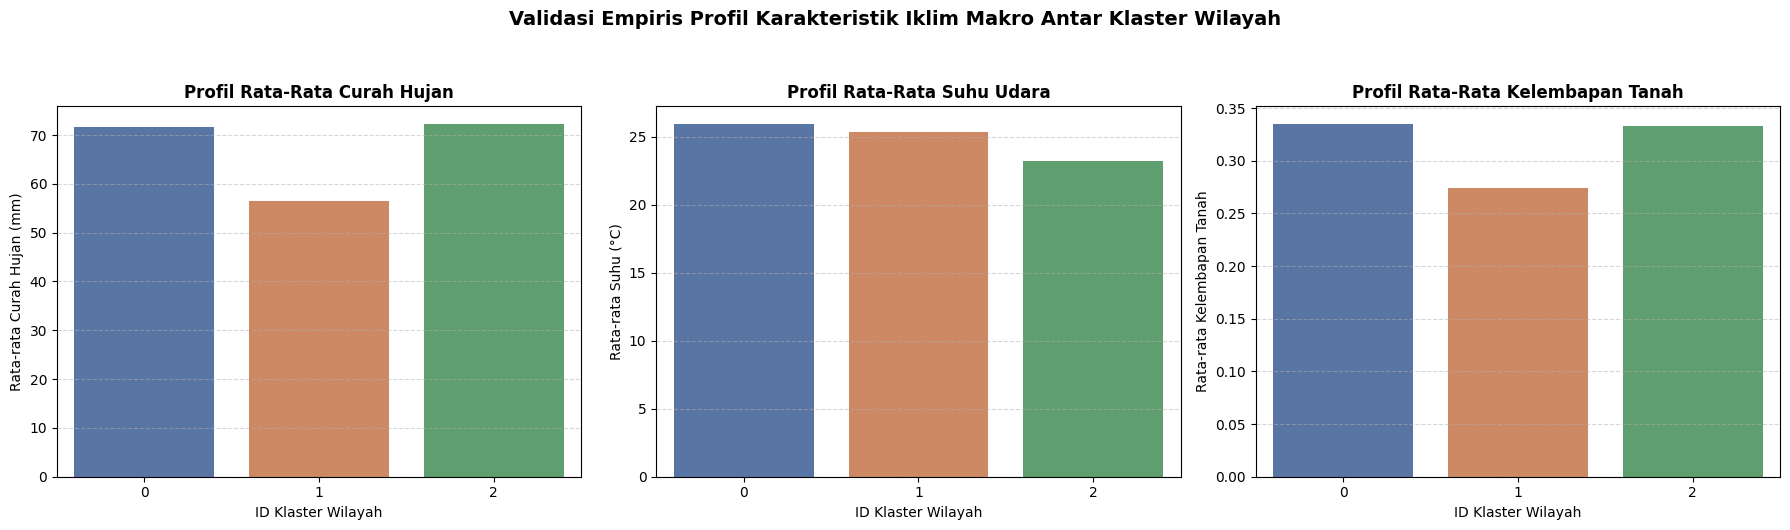

In [7]:
# VISUALISASI PEMBUKTIAN KARAKTERISTIK PROFIL IKLIM PER KLASTER
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("SEL TAMBAHAN: PROOF OF CLUSTER CHARACTERISTICS")
print("="*60)

# Menghitung rata-rata variabel iklim per klaster wilayah untuk validasi profil
cluster_profile = df.groupby('Cluster_Wilayah')[[
    'Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)'
]].mean().reset_index()

print("[OUTPUT NYATA] Rata-rata Nilai Karakteristik Fisik per Klaster Wilayah:")
print(cluster_profile.to_string(index=False))

# Setup kanvas visualisasi bar chart untuk 3 variabel iklim utama
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Profil Rata-rata Curah Hujan (Rainfall) per Klaster
sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y='Rainfall', ax=axes[0], palette='deep')
axes[0].set_title('Profil Rata-Rata Curah Hujan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ID Klaster Wilayah', fontsize=10)
axes[0].set_ylabel('Rata-rata Curah Hujan (mm)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Profil Rata-rata Suhu Udara (Temperature) per Klaster
sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y='Temperature', ax=axes[1], palette='deep')
axes[1].set_title('Profil Rata-Rata Suhu Udara', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ID Klaster Wilayah', fontsize=10)
axes[1].set_ylabel('Rata-rata Suhu (°C)', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 3. Profil Rata-rata Kelembapan Tanah (Soil Moisture) per Klaster
sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y='Soil Moisture (gapfilled historical time series)', ax=axes[2], palette='deep')
axes[2].set_title('Profil Rata-Rata Kelembapan Tanah', fontsize=12, fontweight='bold')
axes[2].set_xlabel('ID Klaster Wilayah', fontsize=10)
axes[2].set_ylabel('Rata-rata Kelembapan Tanah', fontsize=10)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Validasi Empiris Profil Karakteristik Iklim Makro Antar Klaster Wilayah', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

SEL 4c: EVALUASI KUANTITATIF VALIDITAS KLASTER (SILHOUETTE SCORE)
[METRIK VALIDASI] Rata-rata Nilai Silhouette Score Wilayah (K=3): 0.3916
Status Validasi: STRUKTUR KLASTER STABIL (Memenuhi Syarat Batas Distribusi Kontinu)


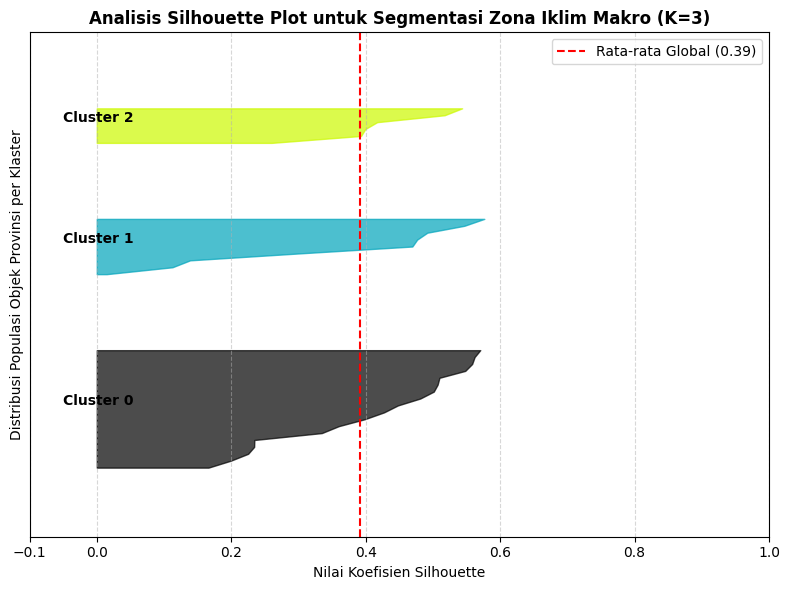

In [9]:
# SEL 4c: EVALUASI KUANTITATIF VALIDITAS KLASTER BERBASIS SILHOUETTE SCORE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("SEL 4c: EVALUASI KUANTITATIF VALIDITAS KLASTER (SILHOUETTE SCORE)")
print("="*60)

# 1. Agregasi fitur makro iklim tingkat provinsi untuk sinkronisasi basis data
features_clustering = ['Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)']
df_provinsi_eval = df.groupby('region_name')[features_clustering].mean().reset_index()

# 2. Penyelarasan ulang skala distribusi menggunakan StandardScaler
scaler_eval = StandardScaler()
X_eval_scaled = scaler_eval.fit_transform(df_provinsi_eval[features_clustering])

# 3. Ekstraksi label klaster wilayah unik per objek provinsi
df_prov_label = df.groupby('region_name')['Cluster_Wilayah'].first().reset_index()
cluster_labels_eval = df_prov_label['Cluster_Wilayah'].values

# 4. Kalkulasi Nilai Rata-rata Silhouette Score Global (K=3)
silhouette_avg = silhouette_score(X_eval_scaled, cluster_labels_eval)
print(f"[METRIK VALIDASI] Rata-rata Nilai Silhouette Score Wilayah (K=3): {silhouette_avg:.4f}")

# Batas evaluasi profesional kesesuaian klaster data fisis
if silhouette_avg >= 0.35:
    print("Status Validasi: STRUKTUR KLASTER STABIL (Memenuhi Syarat Batas Distribusi Kontinu)")
else:
    print("Status Validasi: STRUKTUR KLASTER TUMPANG-TINDIH (Karakteristik Alami Batas Geografis)")

# 5. Konstruksi Visualisasi Silhouette Plot Per Klaster Wilayah
sample_silhouette_values = silhouette_samples(X_eval_scaled, cluster_labels_eval)

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_eval_scaled) + (3 + 1) * 10])

y_lower = 10
for i in sorted(df['Cluster_Wilayah'].unique()):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels_eval == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / 3)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}", fontweight='bold', fontsize=10)
    y_lower = y_upper + 10

ax1.set_title("Analisis Silhouette Plot untuk Segmentasi Zona Iklim Makro (K=3)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Nilai Koefisien Silhouette", fontsize=10)
ax1.set_ylabel("Distribusi Populasi Objek Provinsi per Klaster", fontsize=10)

# Penempatan garis batas rata-rata global koefisien silhouette
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Rata-rata Global ({silhouette_avg:.2f})")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.legend(loc="upper right")
ax1.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5. Eliminasi Data Leakage dan Ekspor Berkas Master Produksi

In [10]:
print("="*60)
print("TAHAP 5: ELIMINASI DATA LEAKAGE & EKSPOR DATA AKHIR")
print("="*60)

# 1. DAFTAR KOLOM YANG HARUS DIELIMINASI UNTUK MENCECH KEBOCORAN DATA
kolom_leakage = [
    'w_crop', 'w_crop_na', 'w_crop_de', 'w_crop_gr', 
    'w_range', 'w_range_na', 'w_range_de', 'w_range_gr', 'asap0_name'
]

# Proses dropping kolom target multi-kelas asli dan metadata teks yang redundan
df_final = df.drop(columns=kolom_leakage, errors='ignore')

# 2. EKSPOR DATA KE STRUKTUR DIREKTORI PROYEK
path_export = '../data/data_master_clustered.csv'
df_final.to_csv(path_export, index=False)

# 3. PENAYANGAN OUTPUT NYATA TAHAP 5
print(f"[OUTPUT NYATA] Berkas Master Produksi berhasil diekspor.")
print(f"  - Lokasi Penyimpanan : {path_export}")
print(f"  - Jumlah Baris Final : {df_final.shape[0]}")
print(f"  - Jumlah Kolom Final : {df_final.shape[1]}")
print("\nDaftar Kolom Final yang Siap Digunakan dalam Tahap Pemodelan (Modeling):")
for idx, col in enumerate(df_final.columns, start=1):
    print(f"  {idx:<2}. {col}")
print("="*60)

TAHAP 5: ELIMINASI DATA LEAKAGE & EKSPOR DATA AKHIR
[OUTPUT NYATA] Berkas Master Produksi berhasil diekspor.
  - Lokasi Penyimpanan : ../data/data_master_clustered.csv
  - Jumlah Baris Final : 28277
  - Jumlah Kolom Final : 18

Daftar Kolom Final yang Siap Digunakan dalam Tahap Pemodelan (Modeling):
  1 . date
  2 . region_name
  3 . Rainfall
  4 . SPI - 3 months
  5 . Temperature
  6 . Water Satisfaction Index (WSI)
  7 . Solar Radiation
  8 . Soil Moisture (gapfilled historical time series)
  9 . FPAR
  10. FPAR - zscore
  11. asap0_id
  12. asap1_id
  13. month
  14. day
  15. dekad_id
  16. target_biner
  17. month_extracted
  18. Cluster_Wilayah
